In [53]:
import pandas as pd
import numpy as np
import os
import time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor 

In [54]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

In [55]:
def add_feature_cross_terms(df, features):
    df_new = df.copy()
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1 = features[i]
            f2 = features[j]
            df_new[f"{f1}_x_{f2}"] = df_new[f1] * df_new[f2]
    return df_new

num_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
train = add_feature_cross_terms(train, num_features)
test = add_feature_cross_terms(test, num_features)

In [56]:
train['Sex'] = train['Sex'].map({'male' : 0, 'female' : 1}).astype('category')
test['Sex'] = test['Sex'].map({'male' : 0, 'female' : 1}).astype('category')

In [57]:
X = train.drop(columns=['id', 'Calories'])
y = np.log1p(train['Calories'])
X_test = test.drop(columns=['id'])

In [ ]:
folds = 50
kf = KFold(n_splits=folds, shuffle=True, random_state=42)

In [59]:
oof_cb = np.zeros(len(train))
oof_xgb = np.zeros(len(train))
pred_cb = np.zeros(len(test))
pred_xgb = np.zeros(len(test))

In [ ]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"CatBoost Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model_cb = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.2,
        early_stopping_rounds=100,
        depth=10,
        l2_leaf_reg=3,
        loss_function='RMSE',
        eval_metric='RMSE',
        verbose=0,
        random_state=42,
        task_type='GPU'if os.environ.get('CUDA_VISIBLE_DEVICES') else 'CPU',
        cat_features=[X.columns.get_loc('Sex')]
    )
    model_cb.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    oof_cb[val_idx] = model_cb.predict(X_val)
    pred_cb += model_cb.predict(X_test)

CatBoost Fold 1
CatBoost Fold 2
CatBoost Fold 3
CatBoost Fold 4


KeyboardInterrupt: 

In [ ]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"XGBoost Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_xgb = XGBRegressor(
        max_depth=10,
        colsample_bytree=0.75,
        subsample=0.9,
        n_estimators=2000,
        learning_rate=0.02,
        gamma=0.01,
        max_delta_step=2,
        early_stopping_rounds=100,
        eval_metric="rmse",
        enable_categorical=True,
        tree_method="gpu_hist" if os.environ.get("CUDA_VISIBLE_DEVICES") else "hist"
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=0)
    oof_xgb[val_idx] = model_xgb.predict(X_val)
    pred_xgb += model_xgb.predict(X_test)

XGBoost Fold 1
XGBoost Fold 2
XGBoost Fold 3
XGBoost Fold 4
XGBoost Fold 5
XGBoost Fold 6
XGBoost Fold 7
XGBoost Fold 8
XGBoost Fold 9
XGBoost Fold 10
XGBoost Fold 11
XGBoost Fold 12
XGBoost Fold 13
XGBoost Fold 14
XGBoost Fold 15
XGBoost Fold 16
XGBoost Fold 17
XGBoost Fold 18
XGBoost Fold 19
XGBoost Fold 20
XGBoost Fold 21
XGBoost Fold 22
XGBoost Fold 23
XGBoost Fold 24
XGBoost Fold 25
XGBoost Fold 26
XGBoost Fold 27
XGBoost Fold 28
XGBoost Fold 29
XGBoost Fold 30
XGBoost Fold 31
XGBoost Fold 32
XGBoost Fold 33
XGBoost Fold 34
XGBoost Fold 35
XGBoost Fold 36
XGBoost Fold 37
XGBoost Fold 38
XGBoost Fold 39
XGBoost Fold 40
XGBoost Fold 41
XGBoost Fold 42
XGBoost Fold 43
XGBoost Fold 44
XGBoost Fold 45
XGBoost Fold 46
XGBoost Fold 47
XGBoost Fold 48
XGBoost Fold 49
XGBoost Fold 50


In [ ]:
pred_cb /= folds
pred_xgb /= folds

In [ ]:
final_pred_log = 0.3 * pred_cb + 0.7 * pred_xgb
final_preds = np.expm1(final_pred_log)
final_preds_clipped = np.clip(final_preds, 1, 314)

In [ ]:
submission['Calories'] = final_preds_clipped
submission.to_csv('submission.csv', index=False)

In [ ]:
oof_pred_log =  0.3 * oof_cb + 0.7 * oof_xgb
oof_preds = np.expm1(oof_pred_log)
oof_preds_clipped = np.clip(oof_preds, 1, 314)

In [ ]:
train_comp = pd.DataFrame({'Actual': train['Calories'], 'Predicted': oof_preds_clipped})

In [ ]:
train_comp['ABS_Error'] = np.abs(train_comp['Actual'] - train_comp['Predicted'])

train_comp_sorted = train_comp.sort_values(by='ABS_Error', ascending=False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

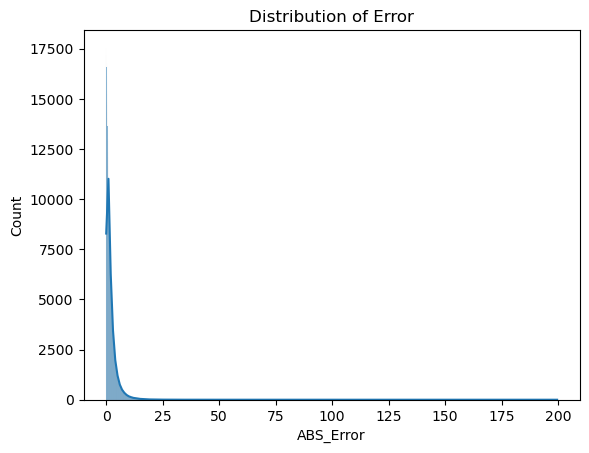

In [ ]:
sns.histplot(train_comp_sorted_bad['Error'], kde=True)
plt.title('Distribution of Error')
plt.xlabel('ABS_Error')
plt.show()


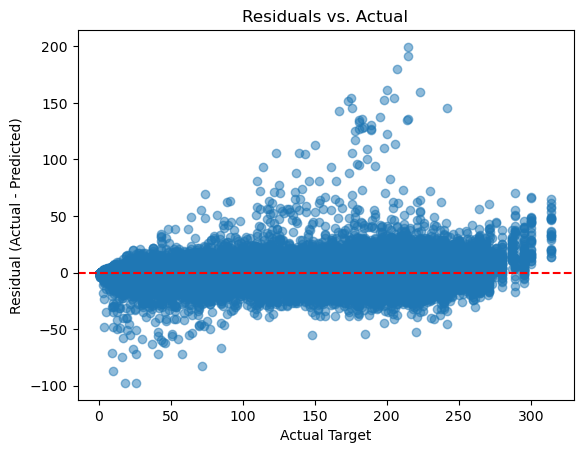

In [ ]:
train_comp['Residual'] = train_comp['Actual'] - train_comp['Predicted']
plt.scatter(train_comp['Actual'], train_comp['Residual'], alpha=0.5)
plt.xlabel("Actual Target")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs. Actual")
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [ ]:
print("Top 5 Worst Predictions:")
print(train_comp_sorted.head())

Top 5 Worst Predictions:
        Actual  Predicted   ABS_Error
214373   215.0  15.478368  199.521632
406697   215.0  23.462045  191.537955
565546   207.0  27.338453  179.661547
558127   200.0  38.869821  161.130179
367163   223.0  63.250702  159.749298


In [ ]:
df_analysis = train.copy()
df_analysis = df_analysis.reset_index(drop=True)  # Ensure indices align
df_analysis['ABS_Error'] = train_comp['ABS_Error']
print(df_analysis.sort_values(by='ABS_Error', ascending=False).head())

            id Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
214373  214373   0   79   200.0    99.0       4.0        76.0       39.0   
406697  406697   0   71   185.0    93.0       6.0        78.0       38.9   
565546  565546   0   60   183.0    80.0       3.0       110.0       38.6   
558127  558127   1   49   160.0    59.0       6.0       112.0       39.5   
367163  367163   0   79   197.0    98.0       2.0       109.0       38.3   

        Calories  Age_x_Height  ...  Height_x_Duration  Height_x_Heart_Rate  \
214373     215.0       15800.0  ...              800.0              15200.0   
406697     215.0       13135.0  ...             1110.0              14430.0   
565546     207.0       10980.0  ...              549.0              20130.0   
558127     200.0        7840.0  ...              960.0              17920.0   
367163     223.0       15563.0  ...              394.0              21473.0   

        Height_x_Body_Temp  Weight_x_Duration  Weight_x_Heart_Rate  

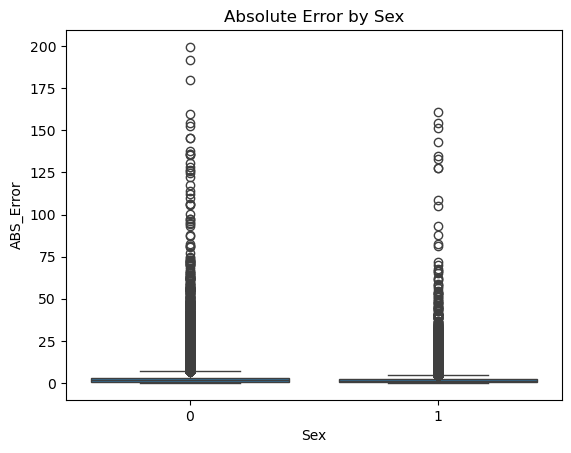

In [ ]:
sns.boxplot(x='Sex', y='ABS_Error', data=df_analysis)
plt.title("Absolute Error by Sex")
plt.show()

C:\Users\km154756\AppData\Local\Temp\ipykernel_15240\329850325.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_error = df_analysis.groupby('Age_bin')['ABS_Error'].mean()


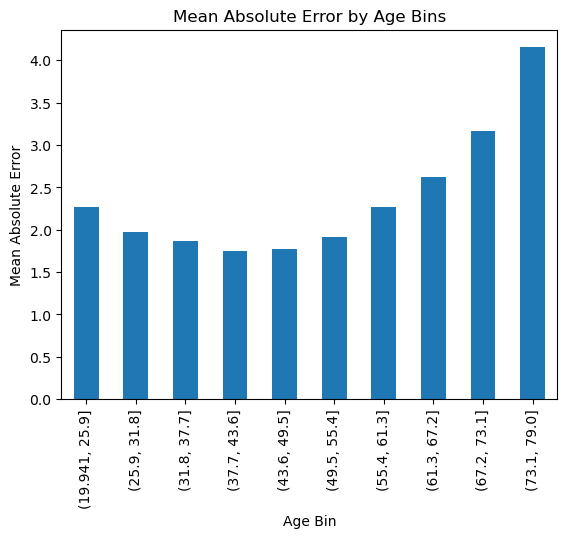

In [ ]:
df_analysis['Age_bin'] = pd.cut(df_analysis['Age'], bins=10)
age_error = df_analysis.groupby('Age_bin')['ABS_Error'].mean()
age_error.plot(kind='bar')
plt.title("Mean Absolute Error by Age Bins")
plt.xlabel("Age Bin")
plt.ylabel("Mean Absolute Error")
plt.show()

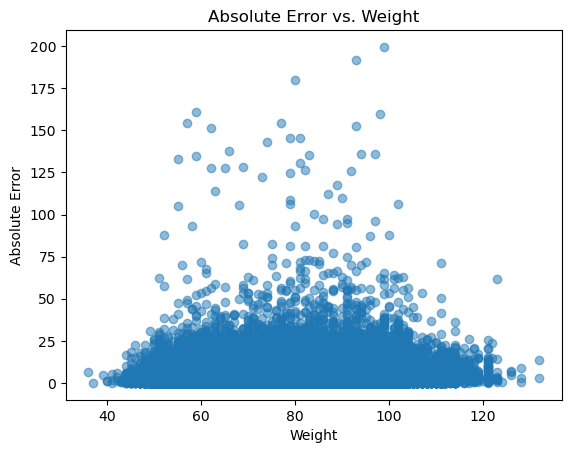

In [ ]:
plt.scatter(df_analysis['Weight'], df_analysis['ABS_Error'], alpha=0.5)
plt.xlabel("Weight")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs. Weight")
plt.show()

In [ ]:
bias_by_sex = df_analysis.groupby('Sex')['ABS_Error'].mean()
print("Bias by Sex:")
print(bias_by_sex)

Bias by Sex:
Sex
0    2.451734
1    1.772787
Name: ABS_Error, dtype: float64


C:\Users\km154756\AppData\Local\Temp\ipykernel_15240\3887132133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bias_by_sex = df_analysis.groupby('Sex')['ABS_Error'].mean()


In [ ]:
numeric_cols = df_analysis.select_dtypes(include=[np.number])
correlation = numeric_cols.corr()['ABS_Error']
print(correlation)

id                        0.001689
Age                       0.075028
Height                    0.076604
Weight                    0.089412
Duration                  0.329415
Heart_Rate                0.308019
Body_Temp                 0.286219
Calories                  0.355689
Age_x_Height              0.090887
Age_x_Weight              0.110658
Age_x_Duration            0.316501
Age_x_Heart_Rate          0.159494
Age_x_Body_Temp           0.090882
Height_x_Weight           0.085506
Height_x_Duration         0.341813
Height_x_Heart_Rate       0.298301
Height_x_Body_Temp        0.149915
Weight_x_Duration         0.349988
Weight_x_Heart_Rate       0.229726
Weight_x_Body_Temp        0.120356
Duration_x_Heart_Rate     0.333561
Duration_x_Body_Temp      0.329508
Heart_Rate_x_Body_Temp    0.313907
ABS_Error                 1.000000
Name: ABS_Error, dtype: float64
